# 参数优化与有效前沿分析

In [1]:
# 导入必要的库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import warnings
from scipy.optimize import minimize, differential_evolution
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

# 环境设置
warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams.update({
    "font.sans-serif": ["WenQuanYi Micro Hei", "SimHei"], 
    "axes.unicode_minus": False, 
    "font.size": 12})

## 1. 数据读取与预处理

In [2]:
# 读取并处理数据
data_path = "/home/haris/project/backtester/para_optimizer_gp/results/optimization_history_trade_support7.json"
with open(data_path, "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.json_normalize(data)

# 列名标准化
column_mapping = {
    "信息比率": "ir", "超额年化收益": "exret", "超额年化波动": "exstd",
    "年化收益": "ret", "最大回撤": "mdd", "超额最大回撤": "exmdd",
    "时间戳": "timestamp", "参数.CITIC_LIMIT": "param_citic_limit",
    "参数.CMVG_LIMIT": "param_cmvg_limit", "参数.STK_HOLD_LIMIT": "param_stock_hold_limit",
    "参数.OTHER_LIMIT": "param_other_limit", "参数.STK_BUY_R": "param_stock_buy_ratio",
    "参数.TURN_MAX": "param_turnover_max", "参数.MEM_HOLD": "param_memory_hold",
}

df = df.rename(columns=column_mapping)
print(f"数据形状: {df.shape}")
display(df.head())

数据形状: (200, 14)


,ir,exret,exstd,ret,mdd,exmdd,timestamp,param_citic_limit,param_cmvg_limit,param_stock_hold_limit,param_other_limit,param_stock_buy_ratio,param_turnover_max,param_memory_hold
0,1.443606,0.148992,0.103208,0.175595,0.482876,0.126961,2026-02-02T11:34:48.805936,0.398271,0.091717,0.015814,0.298425,0.009471,0.046996,0.183700
1,1.678165,0.114081,0.067979,0.140684,0.459589,0.061930,2026-02-02T11:41:01.255789,0.166854,0.071433,0.013367,0.028206,0.014718,0.189554,0.000312
2,1.852597,0.106447,0.057458,0.133051,0.418525,0.051395,2026-02-02T11:47:54.667262,0.496106,0.308741,0.012621,0.003533,0.001438,0.119212,0.159944
3,2.001205,0.115264,0.057597,0.141867,0.404555,0.072063,2026-02-02T11:54:07.294865,0.023333,0.486878,0.005423,0.045303,0.012749,0.095019,0.393292
4,1.433261,0.170867,0.119216,0.197471,0.483574,0.223465,2026-02-02T12:00:17.286350,0.233381,0.429970,0.013926,0.225250,0.001252,0.190174,0.225315


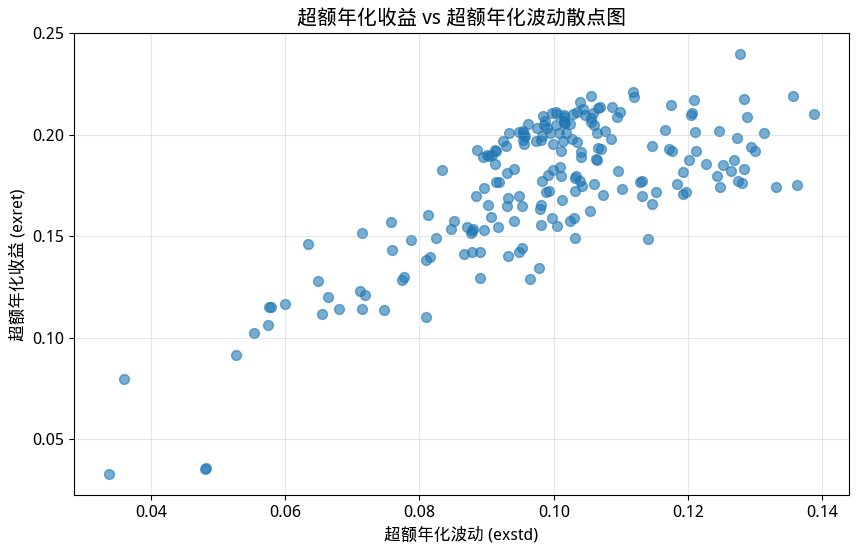

In [3]:
# 原始数据可视化
plt.figure(figsize=(10, 6))
plt.scatter(df['exstd'], df['exret'], alpha=0.6, s=50)
plt.xlabel('超额年化波动 (exstd)')
plt.ylabel('超额年化收益 (exret)')
plt.title('超额年化收益 vs 超额年化波动散点图')
plt.grid(True, alpha=0.3)
plt.show()

## 2. 上凸包计算

In [4]:
def get_upper_convex_hull(points, eps=0.01):
    """
    eps > 0 : 更宽松
    eps = 0 : 标准上凸包
    eps < 0 : 更严格
    """
    points = sorted(points, key=lambda p: (p[0], -p[1]))
    upper_hull = []
    for point in points:
        b = np.array(point)
        if upper_hull and b[1] <= upper_hull[-1][1]:
            continue
        while len(upper_hull) >= 2:
            o = np.array(upper_hull[-2])
            a = np.array(upper_hull[-1])
            u = a - o
            v = b - o
            sin_theta = np.cross(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
            if sin_theta >= eps:
                upper_hull.pop()
            else:
                break
        upper_hull.append(point)
    return upper_hull


def get_upper_convex_hull_with_turnover_diversity(df, eps=0.01, turnover_threshold=0.05):
    """
    获取考虑 turnover_max 参数多样性的上凸包点

    参数:
    df: 包含所有数据的DataFrame
    eps: 凸包松弛度
    turnover_threshold: turnover_max 的最小差异阈值

    返回:
    upper_hull_points: 上凸包点坐标列表 [(exstd, exret), ...]
    hull_indices: 上凸包点在原始df中的索引列表
    """
    # 获取点坐标并排序
    points = list(zip(df["exstd"], df["exret"]))
    points = sorted(points, key=lambda p: (p[0], -p[1]))

    upper_hull = []
    hull_indices = []  # 存储原始数据中的索引

    for point in points:
        b = np.array(point)

        # 如果当前点收益低于上一个点，跳过
        if upper_hull and b[1] <= upper_hull[-1][1]:
            continue

        # 获取当前点的 turnover_max 值
        current_idx = df[(df["exstd"] == point[0]) & (df["exret"] == point[1])].index[0]
        current_turnover = df.loc[current_idx, "param_turnover_max"]

        # 检查 turnover_max 是否与已选点太接近
        should_skip = False
        if upper_hull:
            for hull_idx in hull_indices:
                hull_turnover = df.loc[hull_idx, "param_turnover_max"]
                # 计算 turnover_max 的绝对差异
                turnover_diff = abs(current_turnover - hull_turnover)

                # 如果 turnover_max 太接近，跳过这个点
                if turnover_diff < turnover_threshold:
                    should_skip = True
                    break

        if should_skip:
            continue

        # 凸包判断
        while len(upper_hull) >= 2:
            o = np.array(upper_hull[-2])
            a = np.array(upper_hull[-1])
            u = a - o
            v = b - o
            sin_theta = np.cross(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))

            if sin_theta >= eps:
                # 移除上一个点前，也移除对应的索引
                upper_hull.pop()
                hull_indices.pop()
            else:
                break

        upper_hull.append(point)
        hull_indices.append(current_idx)

    return upper_hull, hull_indices

原始上凸包点数量: 9
考虑 turnover_max 多样性后的上凸包点数量: 5
turnover_max 差异阈值: 0.005

原始上凸包点 (不考虑多样性):


/tmp/ipykernel_2307510/407951636.py:18: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  sin_theta = np.cross(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
/tmp/ipykernel_2307510/407951636.py:80: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  sin_theta = np.cross(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))


,exret,exstd,ir,param_turnover_max
145,0.032732,0.033815,0.967978,0.030000
75,0.079439,0.035985,2.207596,0.120839
162,0.145992,0.063439,2.301309,0.030000
159,0.182548,0.083316,2.191021,0.030000
9,0.192646,0.088514,2.176453,0.032658
197,0.200748,0.093256,2.152661,0.030000
104,0.209181,0.098383,2.126199,0.030000
111,0.219163,0.105567,2.076054,0.030000
106,0.239717,0.127650,1.877919,0.030000



考虑 turnover_max 多样性的上凸包点 (阈值=0.005):


,exret,exstd,ir,param_turnover_max
145,0.032732,0.033815,0.967978,0.030000
75,0.079439,0.035985,2.207596,0.120839
95,0.151439,0.071484,2.118506,0.039461
121,0.191484,0.104095,1.839515,0.062819
29,0.210911,0.120554,1.749516,0.078267


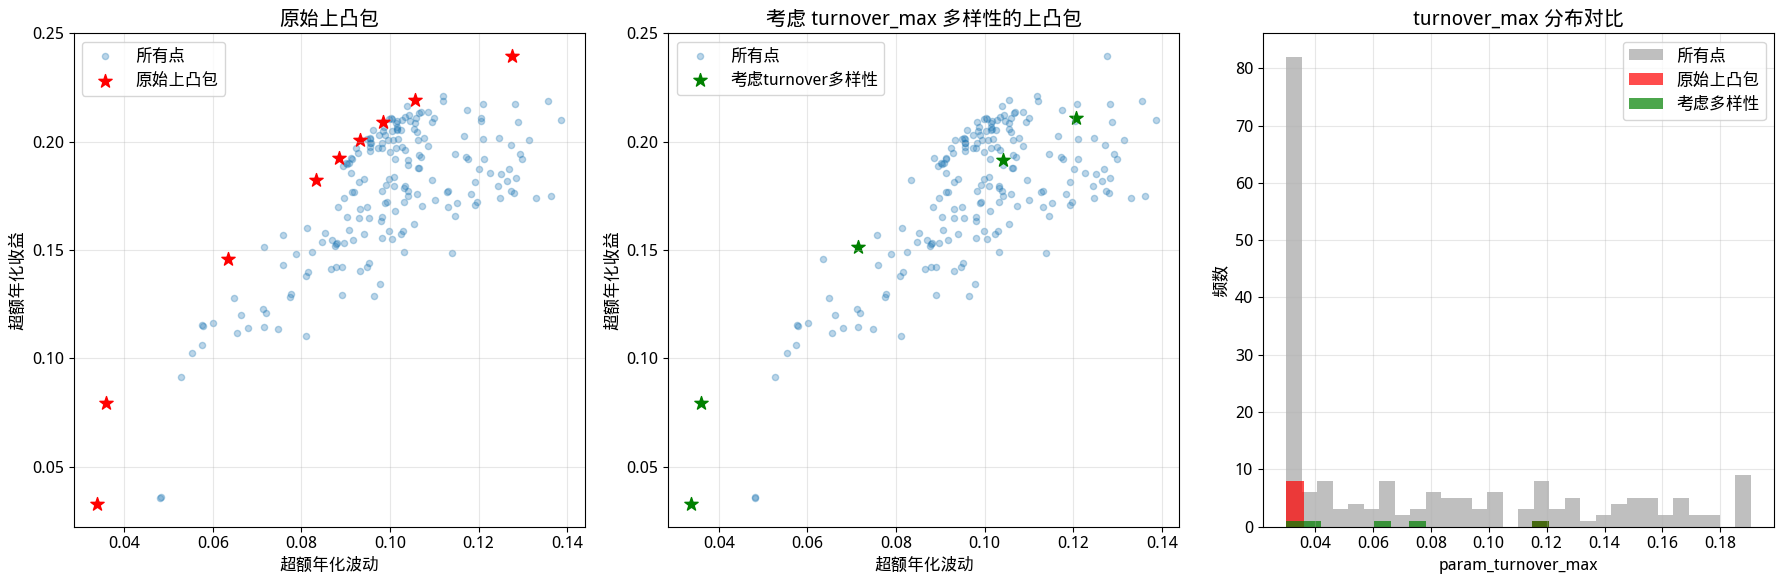

In [5]:
# 使用新的函数
eps_value = 0.01  # 凸包松弛度
turnover_threshold = 0.005  # turnover_max 的最小差异阈值，可以根据实际数据调整

# 先计算原始上凸包（不考虑多样性）
original_upper_hull = get_upper_convex_hull(list(zip(df["exstd"], df["exret"])), eps_value)
original_hull_indices = []
for point in original_upper_hull:
    idx = df[(df["exstd"] == point[0]) & (df["exret"] == point[1])].index[0]
    original_hull_indices.append(idx)

# 计算考虑 turnover 多样性的上凸包
upper_hull_points, hull_indices = get_upper_convex_hull_with_turnover_diversity(df, eps=eps_value, turnover_threshold=turnover_threshold)

print(f"原始上凸包点数量: {len(original_upper_hull)}")
print(f"考虑 turnover_max 多样性后的上凸包点数量: {len(upper_hull_points)}")
print(f"turnover_max 差异阈值: {turnover_threshold}")

# 标记上凸包点
df["is_upper_hull_original"] = False
df.loc[original_hull_indices, "is_upper_hull_original"] = True

df["is_upper_hull_diverse"] = False
df.loc[hull_indices, "is_upper_hull_diverse"] = True

# 显示结果
hull_df_original = df[df["is_upper_hull_original"]].sort_values("exstd")
hull_df_diverse = df[df["is_upper_hull_diverse"]].sort_values("exstd")

print("\n" + "=" * 100)
print("原始上凸包点 (不考虑多样性):")
print("=" * 100)
display(hull_df_original[["exret", "exstd", "ir", "param_turnover_max"]])

print("\n" + "=" * 100)
print(f"考虑 turnover_max 多样性的上凸包点 (阈值={turnover_threshold}):")
print("=" * 100)
display(hull_df_diverse[["exret", "exstd", "ir", "param_turnover_max"]])

# 可视化比较
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 原始散点图（标记所有点）
axes[0].scatter(df["exstd"], df["exret"], alpha=0.3, s=20, label="所有点")
axes[0].scatter(
    df[df["is_upper_hull_original"]]["exstd"], df[df["is_upper_hull_original"]]["exret"], color="red", s=100, marker="*", label="原始上凸包"
)
axes[0].set_xlabel("超额年化波动")
axes[0].set_ylabel("超额年化收益")
axes[0].set_title("原始上凸包")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 考虑 turnover 多样性的散点图
axes[1].scatter(df["exstd"], df["exret"], alpha=0.3, s=20, label="所有点")
axes[1].scatter(
    df[df["is_upper_hull_diverse"]]["exstd"],
    df[df["is_upper_hull_diverse"]]["exret"],
    color="green",
    s=100,
    marker="*",
    label="考虑turnover多样性",
)
axes[1].set_xlabel("超额年化波动")
axes[1].set_ylabel("超额年化收益")
axes[1].set_title(f"考虑 turnover_max 多样性的上凸包")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# turnover_max 分布对比
axes[2].hist(df["param_turnover_max"], bins=30, alpha=0.5, label="所有点", color="gray")
axes[2].hist(hull_df_original["param_turnover_max"], bins=15, alpha=0.7, label="原始上凸包", color="red")
axes[2].hist(hull_df_diverse["param_turnover_max"], bins=15, alpha=0.7, label="考虑多样性", color="green")
axes[2].set_xlabel("param_turnover_max")
axes[2].set_ylabel("频数")
axes[2].set_title("turnover_max 分布对比")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

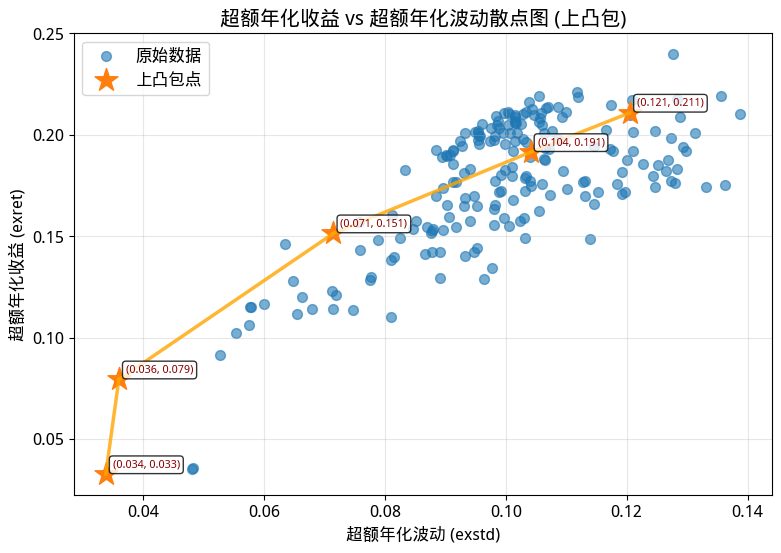

In [6]:
# 绘制上凸包
plt.figure(figsize=(9, 6))
plt.scatter(df['exstd'], df['exret'], alpha=0.6, s=50, label='原始数据')

hull_data = hull_df_diverse
plt.scatter(hull_data['exstd'], hull_data['exret'], 
           marker='*', alpha=1, s=300, label='上凸包点')

# 绘制上凸包连线
hull_sorted = sorted(upper_hull_points, key=lambda p: p[0])
for i in range(len(hull_sorted) - 1):
    plt.plot([hull_sorted[i][0], hull_sorted[i+1][0]], 
            [hull_sorted[i][1], hull_sorted[i+1][1]], 
            '-', color='orange', alpha=0.8, linewidth=2.5)

# 添加坐标标注
for x, y in hull_sorted:
    plt.annotate(f'({x:.3f}, {y:.3f})', 
                (x, y), xytext=(5, 5), 
                textcoords='offset points', fontsize=8, 
                color='darkred',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.xlabel('超额年化波动 (exstd)')
plt.ylabel('超额年化收益 (exret)')
plt.title('超额年化收益 vs 超额年化波动散点图 (上凸包)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. 上凸包的最佳逼近

In [7]:
def inverse_quadratic_model(params, y):
    """二次函数模型: x = a*y^2 + b*y + c"""
    a, b, c = params
    return a * y**2 + b * y + c


def objective_inv(params, y, x):
    """目标函数：最小化预测值与实际值的差距"""
    x_pred = inverse_quadratic_model(params, y)
    return np.sum((x_pred - x)**2)

In [8]:
# 拟合二次函数
hull_y = np.array([p[1] for p in hull_sorted])
hull_x = np.array([p[0] for p in hull_sorted])

initial_guess = [0.1, 0.1, hull_x.min()]
res_inv = minimize(objective_inv, initial_guess, args=(hull_y, hull_x))
a_fit, b_fit, c_fit = res_inv.x

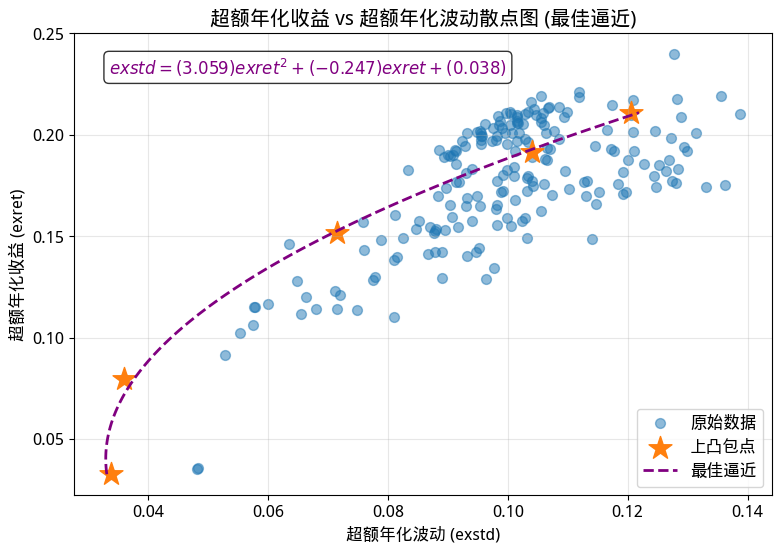

In [9]:
# 绘制拟合曲线
plt.figure(figsize=(9, 6))
plt.scatter(df["exstd"], df["exret"], alpha=0.5, s=50, label="原始数据")
plt.scatter(hull_data['exstd'], hull_data['exret'], 
           marker='*', alpha=1, s=300, label='上凸包点')

y_range = np.linspace(hull_y.min(), hull_y.max(), 100)
x_fit = inverse_quadratic_model([a_fit, b_fit, c_fit], y_range)
plt.plot(x_fit, y_range, "--", color='purple', linewidth=2, label="最佳逼近")

plt.text(0.05, 0.95,
         f"$exstd = ({a_fit:.3f}) exret^2 + ({b_fit:.3f}) exret + ({c_fit:.3f})$",
         transform=plt.gca().transAxes, fontsize=12, color="purple",
         verticalalignment="top",
         bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.xlabel("超额年化波动 (exstd)")
plt.ylabel("超额年化收益 (exret)")
plt.title("超额年化收益 vs 超额年化波动散点图 (最佳逼近)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. 支撑超平面计算有效前沿

In [10]:
def objective_shift(shift):
    """目标函数：最小化平移向量的模长"""
    dx, dy = shift
    return dx**2 + dy**2


def constraint_shift(shift, h_x, h_y, a, b, c):
    """约束条件：平移后的曲线必须在所有凸包点的左侧"""
    dx, dy = shift
    residuals = h_x - (a * (h_y - dy)**2 + b * (h_y - dy) + c + dx)
    return residuals

In [11]:
# 优化有效前沿
initial_guess = [0, 0]
cons = {'type': 'ineq', 'fun': constraint_shift, 'args': (hull_x, hull_y, a_fit, b_fit, c_fit)}
res_opt = minimize(objective_shift, initial_guess, constraints=cons, method='SLSQP')
dx_opt, dy_opt = res_opt.x

# 计算最终参数
a_final = a_fit
b_final = b_fit - 2 * a_fit * dy_opt
c_final = a_fit * dy_opt**2 - b_fit * dy_opt + c_fit + dx_opt

print(f"优化后复合移动距离: {np.sqrt(res_opt.fun):.6f} (dx: {dx_opt:.6f}, dy: {dy_opt:.6f})")
print(f"最终方程: exstd = {a_final:.4f}*exret^2 + {b_final:.4f}*exret + {c_final:.4f}")

优化后复合移动距离: 0.001538 (dx: -0.001497, dy: 0.000353)
最终方程: exstd = 3.0585*exret^2 + -0.2489*exret + 0.0365


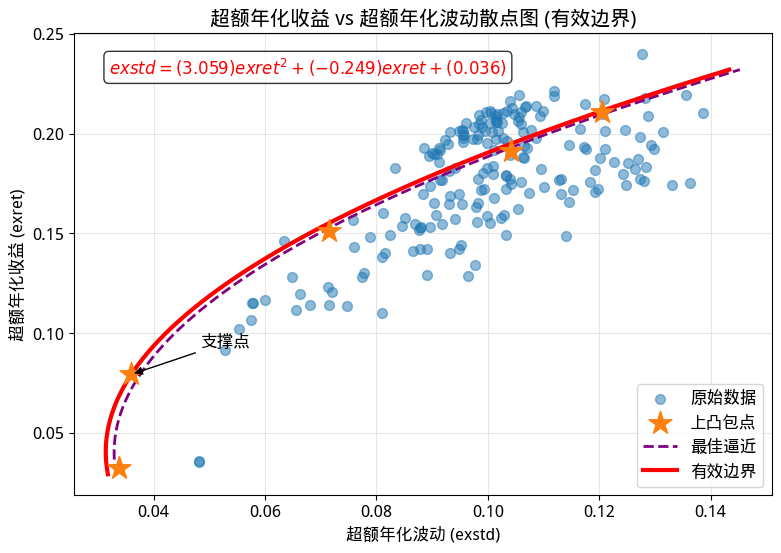

In [12]:
# 绘制有效前沿
plt.figure(figsize=(9, 6))
plt.scatter(df["exstd"], df["exret"], alpha=0.5, s=50, label="原始数据")
plt.scatter(hull_data["exstd"], hull_data["exret"], 
           marker="*", alpha=1, s=300, label="上凸包点", zorder=5)

# 生成曲线数据
y_plot = np.linspace(hull_y.min() * 0.9, hull_y.max() * 1.1, 200)
x_fit_curve = a_fit * y_plot**2 + b_fit * y_plot + c_fit
x_final_curve = a_final * y_plot**2 + b_final * y_plot + c_final

plt.plot(x_fit_curve, y_plot, "--", color="purple", linewidth=2, label="最佳逼近")
plt.plot(x_final_curve, y_plot, "r-", linewidth=3, label="有效边界")

# 标注支撑点
final_errors = hull_x - (a_final * hull_y**2 + b_final * hull_y + c_final)
touch_idx = np.argmin(final_errors)
plt.annotate("支撑点", xy=(hull_x[touch_idx], hull_y[touch_idx]),
             xytext=(50,20), textcoords="offset points",
             arrowprops=dict(arrowstyle="-|>", color="black"), zorder=6)

plt.text(0.05, 0.95,
         f"$exstd = ({a_final:.3f}) exret^2 + ({b_final:.3f}) exret + ({c_final:.3f})$",
         transform=plt.gca().transAxes, fontsize=12, color="r",
         verticalalignment="top",
         bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.xlabel("超额年化波动 (exstd)")
plt.ylabel("超额年化收益 (exret)")
plt.title("超额年化收益 vs 超额年化波动散点图 (有效边界)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. 效率评分

In [13]:
def calculate_efficiency_score(row, a, b, c):
    """计算效率得分：有效前沿对应的最小波动率 - 实际波动率"""
    x_frontier = a * row["exret"]**2 + b * row["exret"] + c
    return x_frontier - row["exstd"]

# 计算效率得分
df["efficiency_score"] = df.apply(
    calculate_efficiency_score, args=(a_final, b_final, c_final), axis=1
)

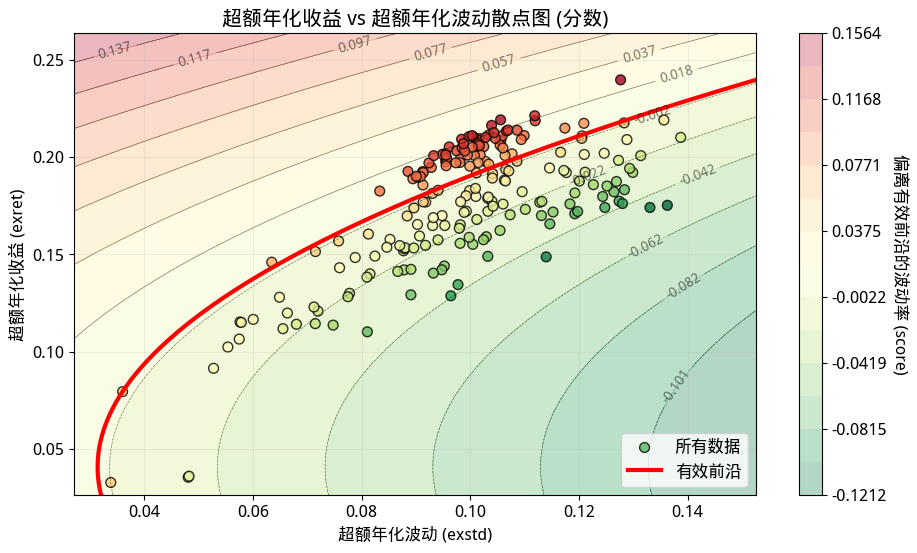

In [14]:
# 绘制效率评分热力图
x_min, x_max = df["exstd"].min() * 0.8, df["exstd"].max() * 1.1
y_min, y_max = df["exret"].min() * 0.8, df["exret"].max() * 1.1

xi, yi = np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200)
Xi, Yi = np.meshgrid(xi, yi)
Zi = a_final * Yi**2 + b_final * Yi + c_final - Xi

plt.figure(figsize=(11, 6))
levels = np.linspace(Zi.min(), Zi.max(), 15)
cp = plt.contourf(Xi, Yi, Zi, levels=levels, cmap="RdYlGn_r", alpha=0.3)
cbar = plt.colorbar(cp)
cbar.set_label("偏离有效前沿的波动率 (score)", rotation=270, labelpad=15)

plt.scatter(df["exstd"], df["exret"], c=df["efficiency_score"], 
           cmap="RdYlGn_r", s=50, edgecolors="k", alpha=0.8, label="所有数据")

CS = plt.contour(Xi, Yi, Zi, levels=levels, colors="k", alpha=0.5, linewidths=0.5)
plt.clabel(CS, inline=True, fontsize=10, fmt="%.3f")

y_plot = np.linspace(y_min, y_max, 200)
x_plot = a_final * y_plot**2 + b_final * y_plot + c_final
plt.plot(x_plot, y_plot, "r-", linewidth=3, label="有效前沿")

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xlabel("超额年化波动 (exstd)")
plt.ylabel("超额年化收益 (exret)")
plt.title("超额年化收益 vs 超额年化波动散点图 (分数)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.2)
plt.show()

## 6. 参数回归分析与优化

In [ ]:
# 参数设置
param_cols = [col for col in df.columns if col.startswith("param_")]
eps = 1e-8

bounds_dict = {
    "param_citic_limit": (eps, 0.5 - eps),
    "param_cmvg_limit": (eps, 0.5 - eps),
    "param_stock_hold_limit": (0.001 + eps, 0.02 - eps),
    "param_other_limit": (eps, 0.5 - eps),
    "param_stock_buy_ratio": (0.001 + eps, 0.02 - eps),
    "param_turnover_max": (0.03 + eps, 0.2 - eps),
    "param_memory_hold": (eps, 0.4 - eps),
}
param_bounds = [bounds_dict[col] for col in param_cols]

# 训练随机森林模型
X_train = df[param_cols]
y_train = df["efficiency_score"]
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

In [ ]:
# 参数优化
search_history = []
max_iters, pop_size = 50, 20
pbar = tqdm(total=max_iters, desc="参数寻优进度")

def objective_func(params_array):
    p_df = pd.DataFrame([params_array], columns=param_cols)
    pred_score = rf_model.predict(p_df)[0]
    search_history.append({**dict(zip(param_cols, params_array)), 
                          "predicted_efficiency_score": pred_score})
    return -pred_score

def monitor_progress(xk, convergence=None):
    pbar.update(1)
    p_df = pd.DataFrame([xk], columns=param_cols)
    current_best = rf_model.predict(p_df)[0]
    pbar.set_postfix({"BestScore": f"{current_best:.6f}"})

# 执行差分进化优化
result_opt = differential_evolution(
    objective_func, param_bounds, strategy="rand1bin", init="latinhypercube",
    popsize=pop_size, maxiter=max_iters, seed=42, callback=monitor_progress,
)
pbar.close()

In [ ]:
# 分散化筛选
history_df = pd.DataFrame(search_history).drop_duplicates(subset=param_cols)
print(f"\n--- 执行分散化筛选 (候选库大小: {len(history_df)}) ---")
turnover_cols = [col for col in param_cols if "turn" in col.lower()]
other_cols = [col for col in param_cols if col not in turnover_cols]

# 标准化时给turnover参数更高权重
scaler = StandardScaler()
X_scaled = scaler.fit_transform(history_df[param_cols])
weight_vector = [1000.0 if col in turnover_cols else 1.0 for col in param_cols]
X_weighted = X_scaled * weight_vector
n_clusters = min(len(history_df), 500)
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
history_df["cluster"] = kmeans.fit_predict(X_weighted)

# 再从每个聚类中取top，合并后取前100
diverse_top_100 = (
    history_df.sort_values("predicted_efficiency_score", ascending=False)
    .groupby("cluster")
    .head(1)
    .head(100)
    .sort_values("predicted_efficiency_score", ascending=False)
)

print(f"已提取 {len(diverse_top_100)} 组高分且重点关注turnover分散的参数。")

In [ ]:
# 保存最终结果
final_samples_df = diverse_top_100[param_cols].head(100)
final_samples_list = final_samples_df.to_dict(orient="records")

# 输出到JSON和CSV文件
json_output_path = "/home/haris/project/backtester/para_optimizer_ef/parameters/diverse_efficient_parameters_std_score_trade_support7.json"
final_samples_df.to_json(json_output_path, orient="records", force_ascii=False, indent=4)

csv_output_path = "/home/haris/project/backtester/para_optimizer_ef/parameters/diverse_efficient_parameters_std_score_trade_support7.csv"
final_samples_df.to_csv(csv_output_path, index=False, encoding="utf-8-sig")

print(f"结果已保存至:")
print(f"- JSON: {json_output_path}")
print(f"- CSV: {csv_output_path}")
print(f"\n最终参数样本数量: {len(final_samples_list)}")

## 7. 实验结果

In [17]:
# 读取并处理数据
data_path = "/home/haris/project/backtester/para_optimizer_ef/scores/diverse_efficient_parameters_std_score_trade_support7.json"
with open(data_path, "r", encoding="utf-8") as f:
    data = json.load(f)

df_exp = pd.json_normalize(data, record_path=["backtest_info"])

result_df = df_exp[["超额年化收益", "超额年化波动"]]

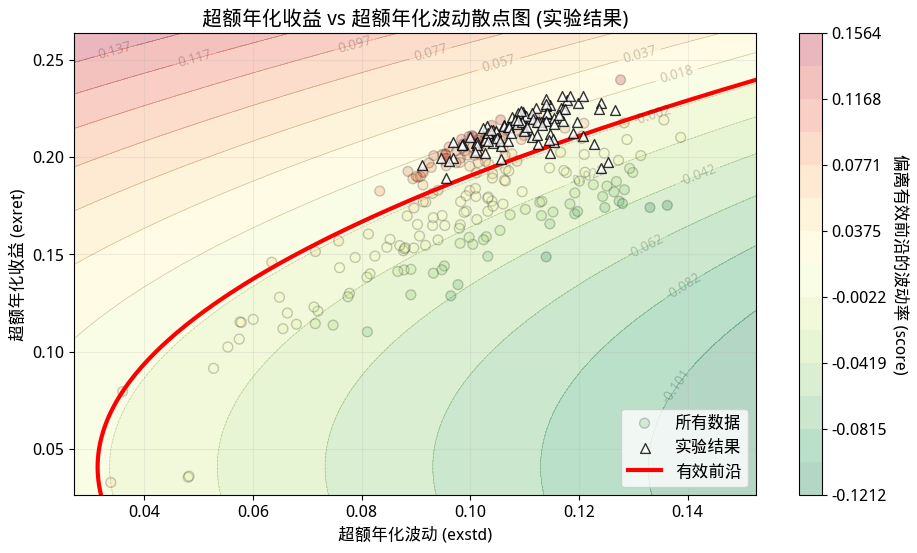

In [18]:
# 绘制效率评分热力图
x_min, x_max = df["exstd"].min() * 0.8, df["exstd"].max() * 1.1
y_min, y_max = df["exret"].min() * 0.8, df["exret"].max() * 1.1

xi, yi = np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200)
Xi, Yi = np.meshgrid(xi, yi)
Zi = a_final * Yi**2 + b_final * Yi + c_final - Xi

plt.figure(figsize=(11, 6))
levels = np.linspace(Zi.min(), Zi.max(), 15)
cp = plt.contourf(Xi, Yi, Zi, levels=levels, cmap="RdYlGn_r", alpha=0.3)
cbar = plt.colorbar(cp)
cbar.set_label("偏离有效前沿的波动率 (score)", rotation=270, labelpad=15)

plt.scatter(df["exstd"], df["exret"], c=df["efficiency_score"], 
           cmap="RdYlGn_r", s=50, edgecolors="k", alpha=0.2, label="所有数据")
plt.scatter(result_df["超额年化波动"], result_df["超额年化收益"], c="w", marker="^", alpha=0.8, s=50, edgecolors="k", label="实验结果", zorder=10)

CS = plt.contour(Xi, Yi, Zi, levels=levels, colors="k", alpha=0.2, linewidths=0.5)
plt.clabel(CS, inline=True, fontsize=10, fmt="%.3f")

y_plot = np.linspace(y_min, y_max, 200)
x_plot = a_final * y_plot**2 + b_final * y_plot + c_final
plt.plot(x_plot, y_plot, "r-", linewidth=3, label="有效前沿")

plt.xlim(x_min, x_max)
plt.ylim(y_min)
plt.xlabel("超额年化波动 (exstd)")
plt.ylabel("超额年化收益 (exret)")
plt.title("超额年化收益 vs 超额年化波动散点图 (实验结果)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.2)
plt.show()